# 05 — Origin of the variance

Where does the noise come from? `slicersim` models each variance source separately. You can
change them, or **switch them off** when getting a spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. The variance sources

In each pixel, the up-the-ramp variance (Rauscher et al. 2007) is

$$\sigma^2 = \sigma^2_\mathrm{RON,eff}(n, m) + \alpha(n, m, d)\; S\,,
\qquad S = \text{total signal in } e^-/\text{s}$$

The signal $S$ is the sum of everything that deposits charge in the pixel. Since all terms add
linearly, each source contributes its own share of the variance. The spectrum variance is then
the sum over the extraction aperture.

In [2]:
import warnings
warnings.filterwarnings("ignore", message="failed to parse")  # harmless internal lookup warning

slicersim.Simulation.VARIANCE_SOURCES

['dark',
 'roic_glow',
 'thermal_dark',
 'ron',
 'pointsource',
 'background',
 'host',
 'thermal']

| source | origin | depends on |
|---|---|---|
| `pointsource` | photon noise of the target itself | target flux |
| `background` | photon noise of the zodiacal light (spatially flat sky) | spaxel area, sky level |
| `host` | photon noise of the host galaxy (none here) | host model |
| `thermal` | thermal emission of the telescope mirrors (293 K) and of the warm spectrograph optics before the disperser; it is dispersed, so it rises in the red | temperatures, emissivities |
| `thermal_dark` | thermal emission of the spectrograph optics after the disperser: not dispersed, a uniform dark-like signal | optics temperatures, emissivities |
| `dark` | detector dark current | `dark` [e-/s/pixel] |
| `roic_glow` | glow of the readout electronics (ROIC), at each frame read: a dark-like signal | `roic_glow` [e-/pixel/frame] |
| `ron` | readout noise, reduced by fitting the ramp | `ron` [e-/frame], `nmd` |

***
## 2. Switch off a variance source

`get_spectrum(switch_off=...)` computes the spectrum as if that source did not exist.

In [3]:
snia = slicersim.LazuliSupernova(redshift=1.0)
_ = snia.setup_to_snr(10, lbda_range=[4000, 7000], frame="rest")

lbda, flux, variance = snia.get_spectrum(incl_error=False)
_, _, variance_noron = snia.get_spectrum(incl_error=False, switch_off="ron")
_, _, variance_nodet = snia.get_spectrum(incl_error=False,
                                         switch_off=["ron", "dark", "roic_glow", "thermal_dark"])

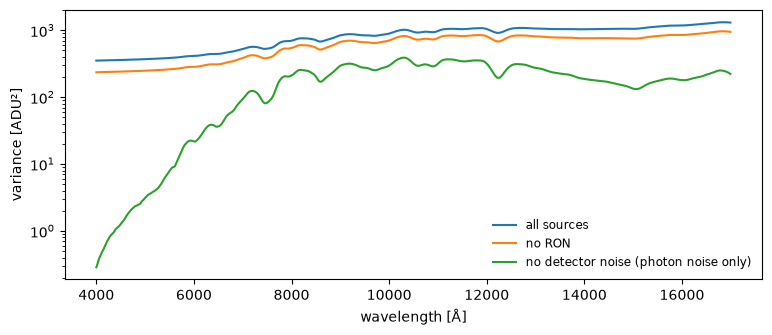

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, variance, label="all sources")
ax.plot(lbda, variance_noron, label="no RON")
ax.plot(lbda, variance_nodet, label="no detector noise (photon noise only)")
ax.set(xlabel="wavelength [Å]", ylabel="variance [ADU²]", yscale="log")
ax.legend(frameon=False, fontsize="small")

Switching off `pointsource` removes the target from the spectrum (signal and photon noise):

In [5]:
_, flux_nosn, variance_nosn = snia.get_spectrum(incl_error=False, switch_off="pointsource")
print("signal:", flux_nosn.max(), "| variance change:", np.mean(1 - variance_nosn / variance).round(3))

signal: 0.0 | variance change: 0.114


Switching off is temporary: the target is unchanged afterwards. To actually **change** a
source, change the corresponding property (notebook 04), e.g. a detector with half the RON:

In [6]:
snr_range = dict(lbda_range=[4000, 7000], frame="rest")
print(f"RON=12 e-: SNR={snia.get_band_snr(**snr_range):.1f}")
snia.change_properties(ron=6)
print(f"RON=6  e-: SNR={snia.get_band_snr(**snr_range):.1f}")
print(f"no RON   : SNR={snia.get_band_snr(**snr_range, switch_off='ron'):.1f}")
snia.change_properties(ron=12)

RON=12 e-: SNR=8.9


RON=6  e-: SNR=9.8


no RON   : SNR=10.1


***
## 3. Scanning the variance sources

The contribution of a source is the variance lost when it is switched off. Looping over all
the sources gives the full variance budget:

In [7]:
budget = {}
for source in slicersim.Simulation.VARIANCE_SOURCES:
    _, _, variance_without = snia.get_spectrum(incl_error=False, switch_off=source)
    budget[source] = variance - variance_without

total = sum(budget.values())
print(f"sum of contributions / total variance: {np.mean(total / variance):.3f}")

sum of contributions / total variance: 1.004


This is exactly what `get_variance_contribution()` does:

In [8]:
contributions = snia.get_variance_contribution()
contributions.head()

,lbda,flux,variance,dark,roic_glow,thermal_dark,ron,pointsource,background,host,thermal
0,3999.990000,0.037523,352.062838,167.651397,63.472260,4.412929,116.239360,0.052478,0.234415,0.0,0.0
1,4004.709303,0.038212,352.120629,167.676681,63.481833,4.413595,116.256891,0.052661,0.238969,0.0,0.0
2,4009.444426,0.038399,352.180808,167.702122,63.491464,4.414264,116.274529,0.052702,0.245727,0.0,0.0
3,4014.195551,0.038387,352.241551,167.727720,63.501156,4.414938,116.292278,0.052701,0.252759,0.0,0.0
4,4018.962861,0.038730,352.302917,167.753478,63.510908,4.415616,116.310136,0.053250,0.259530,0.0,0.0


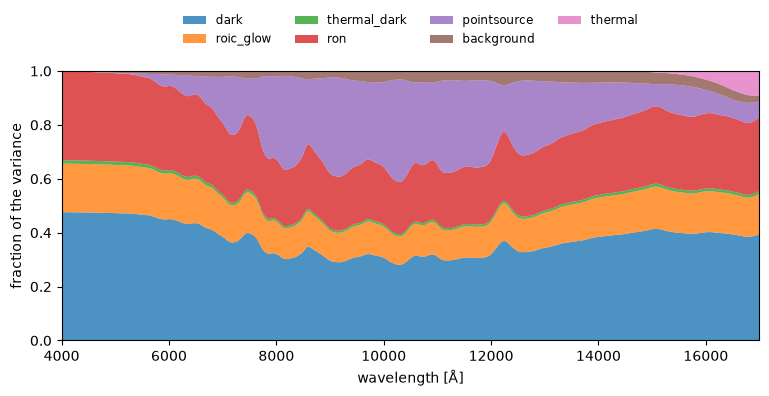

In [9]:
sources = [s for s in slicersim.Simulation.VARIANCE_SOURCES if contributions[s].max() > 0]
fractions = [contributions[s] / contributions["variance"] for s in sources]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.stackplot(contributions["lbda"], fractions, labels=sources, alpha=0.8)
ax.set(xlabel="wavelength [Å]", ylabel="fraction of the variance", ylim=(0, 1),
       xlim=(contributions["lbda"].min(), contributions["lbda"].max()))
ax.legend(ncol=4, fontsize="small", loc="upper center", bbox_to_anchor=(0.5, 1.25), frameon=False)

A summary figure (spectrum, SNR and variance contributions) is also available:

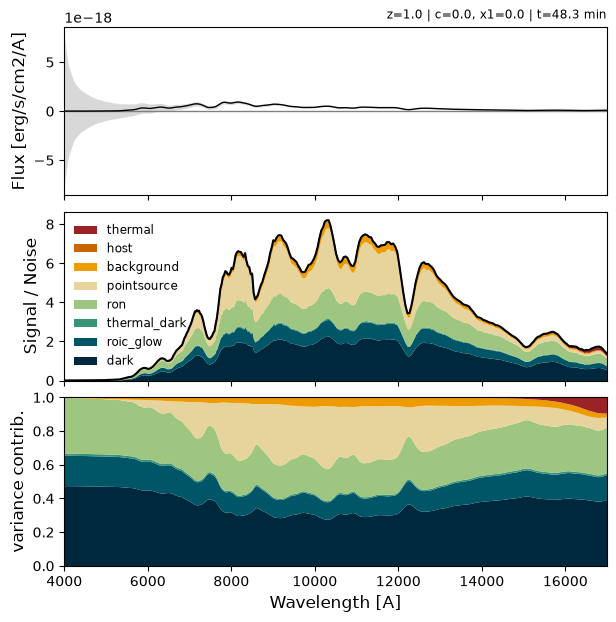

In [10]:
fig = snia.simulation.show_variance_sources(contributions)

### Scan across targets

The same approach tells you which noise source limits a given science case. Here, for SNe Ia
observed at SNR=10, how does the budget in the rest-frame 4000–7000 Å range change with
redshift? (`get_band_variance_contribution()` returns the band-averaged contributions.)

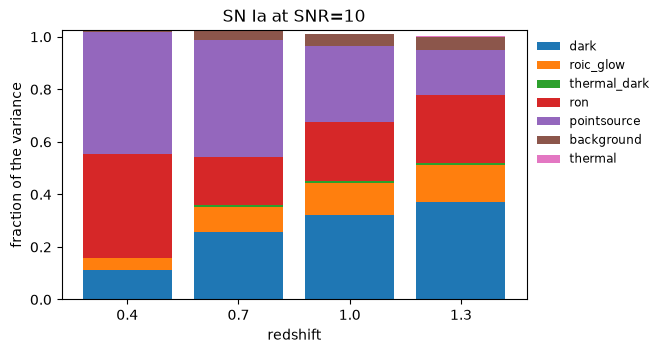

In [11]:
redshifts = [0.4, 0.7, 1.0, 1.3]
fractions = {source: [] for source in sources}
for redshift in redshifts:
    snia.change_properties(redshift=redshift)
    _ = snia.setup_to_snr(10, **snr_range)
    band_budget = snia.simulation.get_band_variance_contribution(**snr_range)
    for source in sources:
        fractions[source].append(band_budget[f"frac_{source}"])

fig, ax = plt.subplots(figsize=(6, 3.5))
bottom = np.zeros(len(redshifts))
for source, frac in fractions.items():
    ax.bar([str(z) for z in redshifts], frac, bottom=bottom, label=source)
    bottom += frac
ax.set(xlabel="redshift", ylabel="fraction of the variance", title="SN Ia at SNR=10")
ax.legend(fontsize="small", bbox_to_anchor=(1, 1), frameon=False)

***
## Recap

- Variance sources: `slicersim.Simulation.VARIANCE_SOURCES`.
- `get_spectrum(switch_off=[...])` (also `get_band_snr`, `get_cube`) temporarily removes sources.
- `change_properties()` changes them permanently (e.g. `ron`, `dark`, `roic_glow`).
- `get_variance_contribution()` scans all sources; `simulation.show_variance_sources()` plots
  the result.

**Next:** [06 — Cubes, the two Lazuli fields and the detector](06_cubes_and_fields.ipynb)